In [1]:
!git clone https://github.com/hossambalaha/hmbd-v1.git

Cloning into 'hmbd-v1'...
remote: Enumerating objects: 54242, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 54242 (delta 1), reused 3 (delta 1), pack-reused 54235 (from 1)
Receiving objects: 100% (54242/54242), 230.97 MiB | 10.54 MiB/s, done.
Resolving deltas: 100% (2128/2128), done.
Updating files: 100% (54119/54119), done.


In [2]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import os

In [3]:
data_dir = '/content/hmbd-v1/Dataset'
images = []
labels = []
digits = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']

for label, digit in enumerate(digits):
    digit_dir = os.path.join(data_dir, digit)
    if os.path.isdir(digit_dir):
        for img_name in os.listdir(digit_dir):
            img_path = os.path.join(digit_dir, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (150, 150))
            images.append(image)
            labels.append(label)

images = np.array(images).reshape(-1, 150, 150, 1) / 255.0
labels = to_categorical(np.array(labels), 10)

images_rgb = np.array([cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB) for img in images])
images_rgb = preprocess_input(images_rgb)

X_train, X_test, y_train, y_test = train_test_split(images_rgb, labels, test_size=0.2, random_state=42)

In [5]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=16)

In [6]:
xception_model = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

input_layer = Input(shape=(150, 150, 3))
x = xception_model(input_layer, training=True)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
out_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=out_layer)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 5, 5, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,553,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,416,498 (104.59 MB)

 Trainable params: 27,361,970 (104.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'digit_recognition_model_xception.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.1839 - loss: 2.2962
Epoch 1: val_accuracy improved from -inf to 0.09705, saving model to digit_recognition_model_xception.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 112s 261ms/step - accuracy: 0.1842 - loss: 2.2954 - val_accuracy: 0.0970 - val_loss: 10.8317
Epoch 2/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4547 - loss: 1.6420
Epoch 2: val_accuracy improved from 0.09705 to 0.58439, saving model to digit_recognition_model_xception.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.4550 - loss: 1.6412 - val_accuracy: 0.5844 - val_loss: 1.9563
Epoch 3/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7489 - loss: 0.7940
Epoch 3: val_accuracy improved from 0.58439 to 0.71203, saving model to digit_recognition_model_xception.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.7489 - loss: 0.7939 - val_accuracy: 0.7120 - val_loss: 0.9768
Epoch 4/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [8]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.3144
Test Loss: 0.1285
Training Accuracy: 91.58%
Test Accuracy: 95.25%


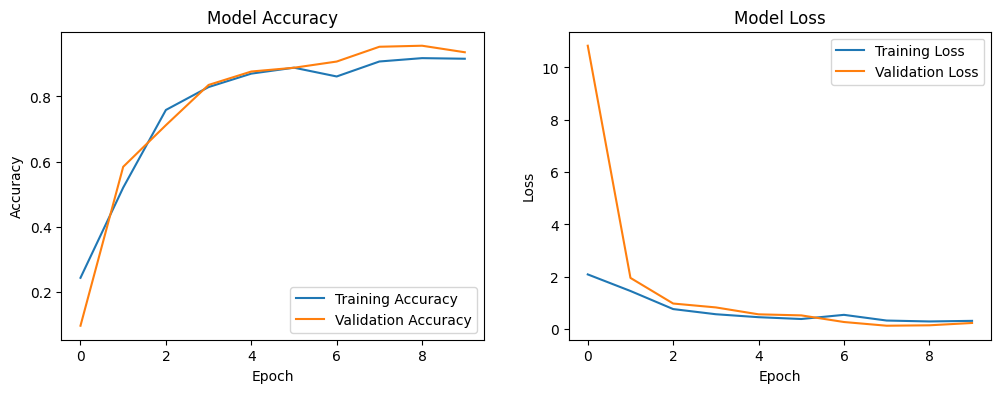

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step


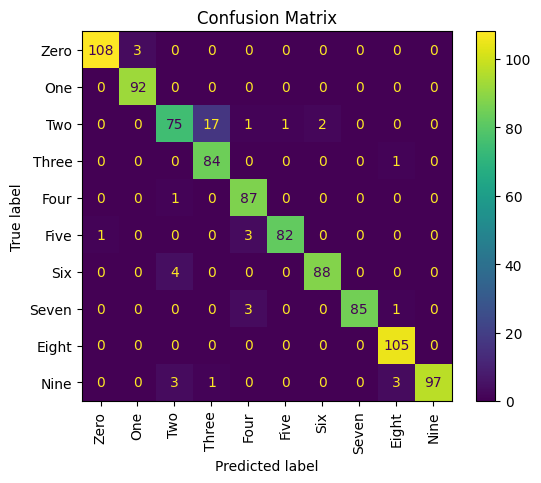

In [10]:
!pip install scikit-learn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=digits)
disp.plot(cmap='viridis', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted Digit: 8


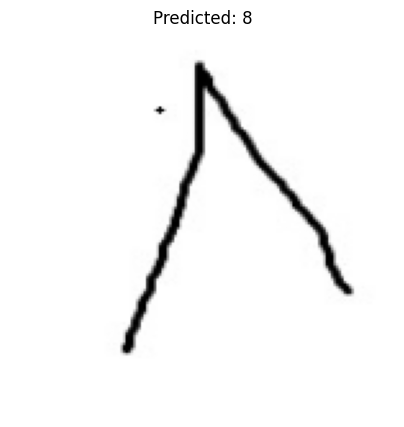

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_image_path = '/content/eight8.jpg'

image = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if image is not None:
    image = cv2.resize(image, (150, 150))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image_rgb = image_rgb / 255.0
    image_rgb = np.expand_dims(image_rgb, axis=0)

    prediction = model.predict(image_rgb)

    predicted_class = np.argmax(prediction, axis=1)[0]

    print(f"Predicted Digit: {predicted_class}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("Error: Unable to load the image. Please check the file path.")
